<a href="https://colab.research.google.com/github/IsabelaZa26/Seguimiento-1/blob/main/Clase1_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase 1 — Fundamentos del Aprendizaje Automático
**Introducción a la Minería de Datos · Universidad Nacional de Colombia, Medellín**

---
### Objetivos de este notebook
1. Configurar el entorno de trabajo con las librerías estándar de ML
2. Explorar y preparar un dataset real
3. Aplicar el ciclo Representar → Entrenar → Evaluar → Refinar
4. Visualizar overfitting y underfitting en la práctica

**Dataset:** Precios de vivienda (`California Housing` de scikit-learn) + datos sintéticos para ilustrar conceptos.

> 💡 **Cómo trabajar este notebook:** ejecuta cada celda en orden (`Shift+Enter`). Las celdas marcadas con ✏️ tienen ejercicios para completar.

## 0. Importaciones y configuración

In [1]:
# ── Librerías estándar ──────────────────────────────────
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ────────────────────────────────────────
from sklearn.datasets        import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LinearRegression
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import mean_squared_error, r2_score

# ── Estética ────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (9, 5)})
SEED = 42
np.random.seed(SEED)

print('✓ Entorno listo')

✓ Entorno listo


## 1. El problema — datos de vivienda

Usamos el dataset **California Housing** (20,640 distritos de California, 1990).  
Es análogo a nuestro ejemplo de Medellín: características de la zona → precio mediano.

In [2]:
# Cargar datos
data = fetch_california_housing(as_frame=True)
df   = data.frame

print(f'Shape: {df.shape}')
print(f'Target: precio mediano de la vivienda (en 100,000 USD)')
df.head()

Shape: (20640, 9)
Target: precio mediano de la vivienda (en 100,000 USD)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Estadísticas descriptivas — como estadísticos, esto es lo primero
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


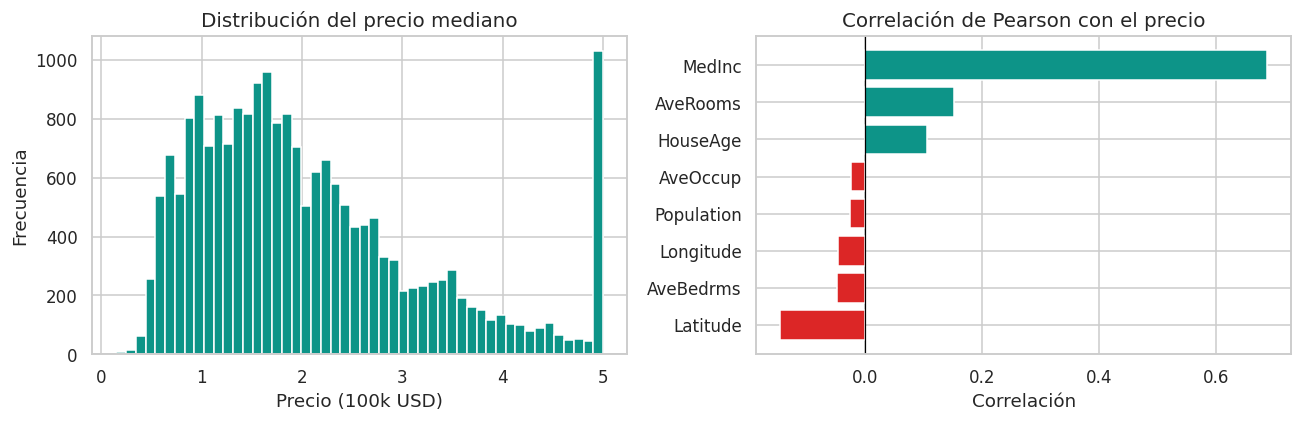


Variable más correlacionada: MedInc


In [4]:
# Distribución del target y correlaciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución del precio
axes[0].hist(df['MedHouseVal'], bins=50, color='#0D9488', edgecolor='white')
axes[0].set_title('Distribución del precio mediano', fontsize=13)
axes[0].set_xlabel('Precio (100k USD)')
axes[0].set_ylabel('Frecuencia')

# Correlación con el target
corrs = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['#DC2626' if c < 0 else '#0D9488' for c in corrs]
axes[1].barh(corrs.index, corrs.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación de Pearson con el precio', fontsize=13)
axes[1].set_xlabel('Correlación')

plt.tight_layout()
plt.show()

print('\nVariable más correlacionada:', corrs.abs().idxmax())

## 2. El ciclo ML — Representar → Entrenar → Evaluar

In [5]:
# ── PASO 1: Representar — definir X e y ─────────────────
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print(f'X: {X.shape}  →  {X.shape[0]} muestras, {X.shape[1]} features')
print(f'y: {y.shape}  →  variable continua (regresión)')

X: (20640, 8)  →  20640 muestras, 8 features
y: (20640,)  →  variable continua (regresión)


In [6]:
# ── PASO 2: División entrenamiento / prueba ──────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')
print()
print('REGLA DE ORO: a partir de aquí, X_test y y_test')
print('NO se tocan hasta la evaluación final.')

Entrenamiento: 16512 muestras
Prueba:        4128 muestras

REGLA DE ORO: a partir de aquí, X_test y y_test
NO se tocan hasta la evaluación final.


In [7]:
# ── PASO 3: Entrenar — usando un Pipeline ───────────────
# Pipeline = escalar + modelo en una sola cadena
pipe = Pipeline([
    ('scaler', StandardScaler()),      # normaliza a media 0, desv. 1
    ('model',  LinearRegression()),
])

pipe.fit(X_train, y_train)
print('✓ Modelo entrenado')

✓ Modelo entrenado


In [8]:
# ── PASO 4: Evaluar ─────────────────────────────────────
y_pred_train = pipe.predict(X_train)
y_pred_test  = pipe.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)

rmse_train = np.sqrt(mse_train)
rmse_test  = np.sqrt(mse_test)
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

print(f'{'Métrica':<12} {'Entrenamiento':>16} {'Prueba':>10}')
print('-' * 42)
print(f'{'RMSE':<12} {rmse_train:>16.3f} {rmse_test:>10.3f}')
print(f'{'R²':<12} {r2_train:>16.3f} {r2_test:>10.3f}')

print()
# Diagnóstico automático
gap = rmse_test - rmse_train
if gap < 0.05:
    print('✓ Diferencia train/test pequeña → buen ajuste')
elif gap < 0.15:
    print('⚠ Leve overfitting — considerar regularización')
else:
    print('✗ Overfitting importante — el modelo no generaliza bien')

Métrica         Entrenamiento     Prueba
------------------------------------------
RMSE                    0.720      0.746
R²                      0.613      0.576

✓ Diferencia train/test pequeña → buen ajuste


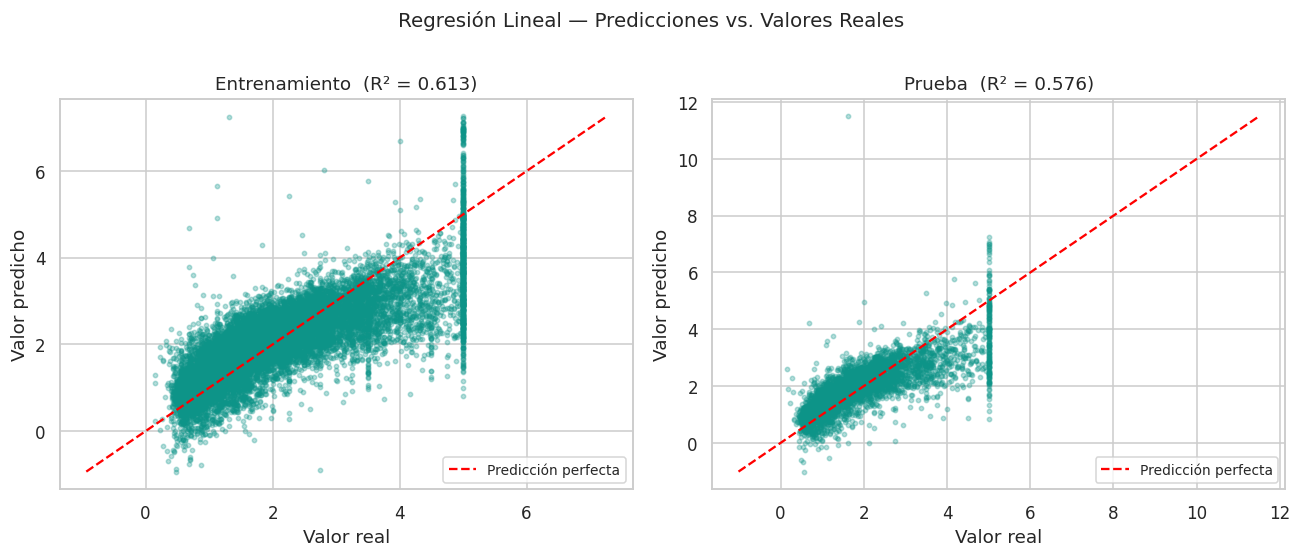

In [9]:
# Gráfico de predicciones vs. valores reales
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (y_true, y_p, label) in zip(axes, [
    (y_train, y_pred_train, 'Entrenamiento'),
    (y_test,  y_pred_test,  'Prueba')
]):
    ax.scatter(y_true, y_p, alpha=0.3, s=8, color='#0D9488')
    lims = [min(y_true.min(), y_p.min()), max(y_true.max(), y_p.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor predicho')
    ax.set_title(f'{label}  (R² = {r2_score(y_true, y_p):.3f})')
    ax.legend(fontsize=9)

plt.suptitle('Regresión Lineal — Predicciones vs. Valores Reales', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

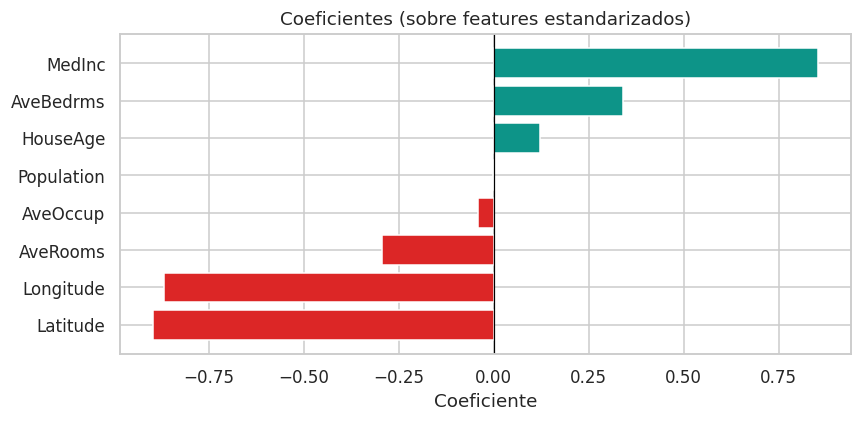

Intercepto: 2.072


In [10]:
# Coeficientes del modelo — interpretación estadística
coef = pd.Series(
    pipe.named_steps['model'].coef_,
    index=X.columns
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#DC2626' if c < 0 else '#0D9488' for c in coef]
ax.barh(coef.index, coef.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes (sobre features estandarizados)', fontsize=12)
ax.set_xlabel('Coeficiente')
plt.tight_layout()
plt.show()

print('Intercepto:', pipe.named_steps['model'].intercept_.round(3))

## 3. Visualizar Overfitting y Underfitting

Usamos un dataset sintético con señal no lineal para ver los tres escenarios.

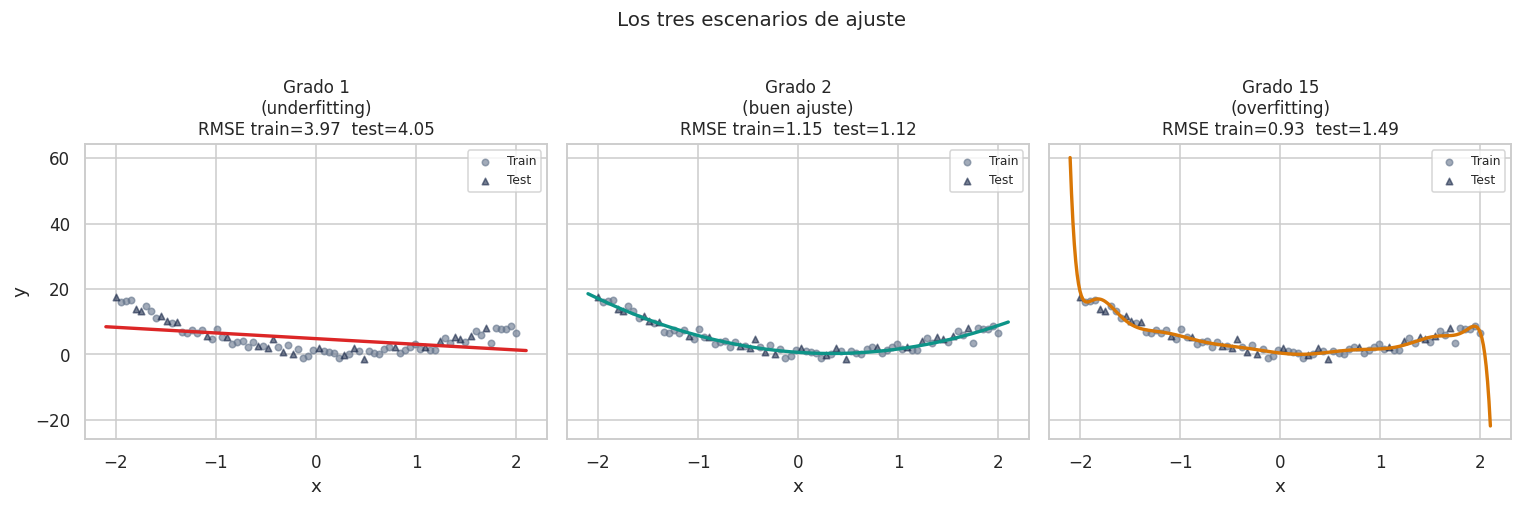

In [11]:
from sklearn.preprocessing   import PolynomialFeatures
from sklearn.pipeline        import make_pipeline

# Dataset sintético: y = 3x² - 2x + 1 + ruido
np.random.seed(SEED)
n = 80
x_syn = np.linspace(-2, 2, n)
y_syn = 3*x_syn**2 - 2*x_syn + 1 + np.random.normal(0, 1.2, n)

X_syn = x_syn.reshape(-1, 1)
Xtr, Xte, ytr, yte = train_test_split(X_syn, y_syn, test_size=0.3, random_state=SEED)

# Modelos de distinta complejidad
grados = [1, 2, 15]          # underfitting, correcto, overfitting
labels = ['Grado 1\n(underfitting)', 'Grado 2\n(buen ajuste)', 'Grado 15\n(overfitting)']
colors_m = ['#DC2626', '#0D9488', '#D97706']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
x_plot = np.linspace(-2.1, 2.1, 300).reshape(-1, 1)

for ax, grado, label, color in zip(axes, grados, labels, colors_m):
    m = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    m.fit(Xtr, ytr)

    mse_tr = mean_squared_error(ytr, m.predict(Xtr))
    mse_te = mean_squared_error(yte, m.predict(Xte))

    rmse_tr = np.sqrt(mse_tr)
    rmse_te = np.sqrt(mse_te)

    ax.scatter(Xtr, ytr, s=18, alpha=0.6, color='#64748B', label='Train')
    ax.scatter(Xte, yte, s=18, alpha=0.6, color='#1B2A4A', label='Test', marker='^')
    ax.plot(x_plot, m.predict(x_plot), color=color, linewidth=2.2)
    ax.set_title(f'{label}\nRMSE train={rmse_tr:.2f}  test={rmse_te:.2f}', fontsize=11)
    ax.set_xlabel('x')
    if ax == axes[0]: ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle('Los tres escenarios de ajuste', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

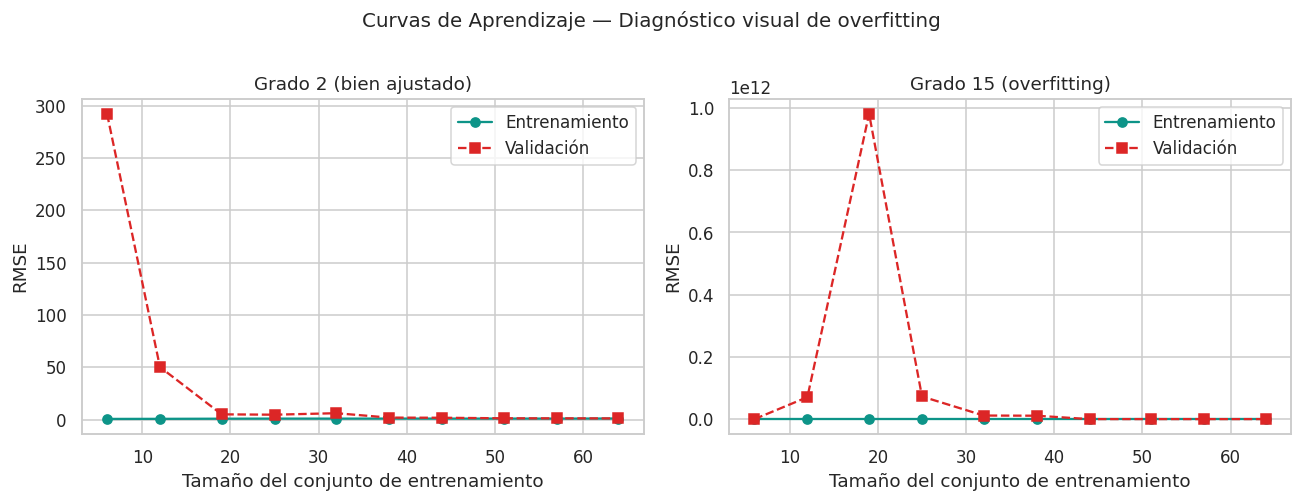


Interpretación:
  Grado 2:  curvas convergen → modelo equilibrado
  Grado 15: gap grande entre train y val → overfitting


In [12]:
# ── Curvas de aprendizaje ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, grado, titulo in zip(axes, [2, 15], ['Grado 2 (bien ajustado)', 'Grado 15 (overfitting)']):
    m = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    train_sizes, train_scores, val_scores = learning_curve(
        m, X_syn, y_syn, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_root_mean_squared_error',
        random_state=SEED
    )
    tr_m = -train_scores.mean(axis=1)
    va_m = -val_scores.mean(axis=1)

    ax.plot(train_sizes, tr_m, 'o-', color='#0D9488', label='Entrenamiento')
    ax.plot(train_sizes, va_m, 's--', color='#DC2626', label='Validación')
    ax.fill_between(train_sizes,
                    tr_m - train_scores.std(axis=1),
                    tr_m + train_scores.std(axis=1), alpha=0.15, color='#0D9488')
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('RMSE')
    ax.legend()

plt.suptitle('Curvas de Aprendizaje — Diagnóstico visual de overfitting', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print()
print('Interpretación:')
print('  Grado 2:  curvas convergen → modelo equilibrado')
print('  Grado 15: gap grande entre train y val → overfitting')

## 4. Parámetros e Hiperparámetros en la práctica

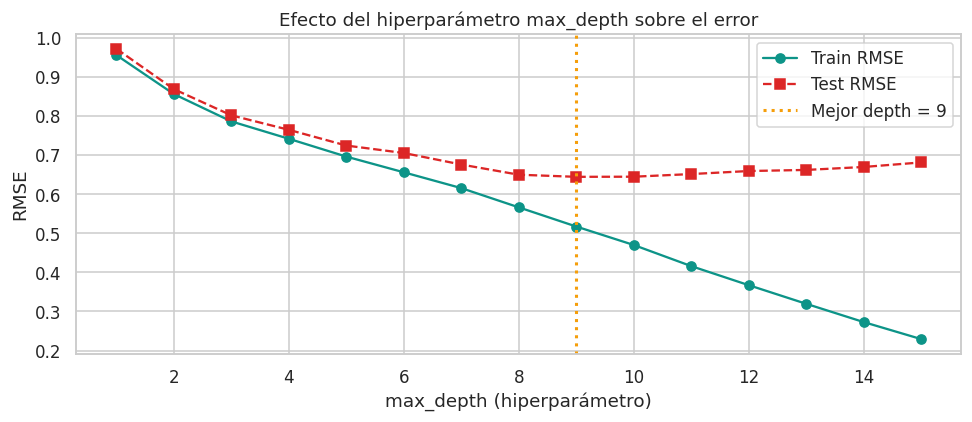

Mejor profundidad según test RMSE: 9
Nota: esta selección TAMBIÉN debería hacerse con validación cruzada (Clase 2)


In [13]:
from sklearn.tree import DecisionTreeRegressor

# Efecto del hiperparámetro max_depth en un árbol de decisión
profundidades = range(1, 16)
rmse_tr_list, rmse_te_list = [], []

for d in profundidades:
    tree = DecisionTreeRegressor(max_depth=d, random_state=SEED)
    tree.fit(X_train, y_train)

    mse_tr = mean_squared_error(y_train, tree.predict(X_train))
    mse_te = mean_squared_error(y_test,  tree.predict(X_test))

    rmse_tr_list.append(np.sqrt(mse_tr))
    rmse_te_list.append(np.sqrt(mse_te))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(profundidades, rmse_tr_list, 'o-', color='#0D9488', label='Train RMSE')
ax.plot(profundidades, rmse_te_list, 's--', color='#DC2626', label='Test RMSE')
mejor_d = profundidades[np.argmin(rmse_te_list)]
ax.axvline(mejor_d, color='#F59E0B', linestyle=':', linewidth=2, label=f'Mejor depth = {mejor_d}')
ax.set_xlabel('max_depth (hiperparámetro)')
ax.set_ylabel('RMSE')
ax.set_title('Efecto del hiperparámetro max_depth sobre el error', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mejor profundidad según test RMSE: {mejor_d}')
print('Nota: esta selección TAMBIÉN debería hacerse con validación cruzada (Clase 2)')

## ✏️ Ejercicios

### Ejercicio 1 — Exploración del dataset
Identificar las 3 features con mayor correlación absoluta con el precio.  
¿Tienen sentido desde el punto de vista económico?

In [14]:
# Correlaciones de todas las features con el precio
corr_target = (
    df.corr(numeric_only=True)['MedHouseVal']
    .drop('MedHouseVal')
    .sort_values(key=abs, ascending=False)
)

# Seleccionar las 3 features con mayor correlación absoluta
top3_corr = corr_target.head(3).reset_index()
top3_corr.columns = ['Feature', 'Correlación con MedHouseVal']

print('Top 3 features con mayor correlación absoluta con el precio:')
print(top3_corr.round(4))


Top 3 features con mayor correlación absoluta con el precio:
    Feature  Correlación con MedHouseVal
0    MedInc                       0.6881
1  AveRooms                       0.1519
2  Latitude                      -0.1442


Las tres variables con mayor correlación absoluta con el precio mediano de la vivienda fueron MedInc, AveRooms y Latitude. La variable MedInc presentó la correlación más alta y positiva, lo cual tiene sentido desde el punto de vista económico, ya que zonas con mayores ingresos medianos suelen tener viviendas de mayor valor. La variable AveRooms también mostró una relación positiva, aunque más débil, indicando que viviendas con más habitaciones promedio tienden a asociarse con precios más altos. Finalmente, Latitude presentó una correlación negativa, lo que sugiere que existen diferencias geográficas asociadas al precio. Sin embargo, esta última variable debe interpretarse con cautela, pues no representa directamente una causa económica, sino una característica espacial del territorio.

### Ejercicio 2 — Una sola variable
Ajustar una regresión lineal usando únicamente la variable `MedInc`.  
Comparar el R² con el modelo de todas las variables.  
¿Cuánta varianza explica solo el ingreso mediano?

In [15]:
# Variable explicativa única
X_medinc = df[['MedInc']]
y = df['MedHouseVal']

X_train_medinc, X_test_medinc, y_train_medinc, y_test_medinc = train_test_split(
    X_medinc, y,
    test_size=0.2,
    random_state=SEED
)

# Pipeline: escalar + regresión lineal
pipe_medinc = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Entrenar modelo
pipe_medinc.fit(X_train_medinc, y_train_medinc)

# Predicciones
y_pred_train_medinc = pipe_medinc.predict(X_train_medinc)
y_pred_test_medinc  = pipe_medinc.predict(X_test_medinc)

# Métricas del modelo con una variable
r2_train_medinc = r2_score(y_train_medinc, y_pred_train_medinc)
r2_test_medinc  = r2_score(y_test_medinc, y_pred_test_medinc)

rmse_train_medinc = np.sqrt(mean_squared_error(y_train_medinc, y_pred_train_medinc))
rmse_test_medinc  = np.sqrt(mean_squared_error(y_test_medinc, y_pred_test_medinc))

print('Modelo usando únicamente MedInc')
print('-' * 45)
print(f'R² entrenamiento: {r2_train_medinc:.4f}')
print(f'R² prueba:        {r2_test_medinc:.4f}')
print(f'RMSE entrenamiento: {rmse_train_medinc:.4f}')
print(f'RMSE prueba:        {rmse_test_medinc:.4f}')

Modelo usando únicamente MedInc
---------------------------------------------
R² entrenamiento: 0.4770
R² prueba:        0.4589
RMSE entrenamiento: 0.8361
RMSE prueba:        0.8421


Al ajustar una regresión lineal usando únicamente la variable MedInc, se obtuvo un R² de prueba aproximado de 0.459. Esto significa que el ingreso mediano por sí solo explica cerca del 45.9% de la variabilidad del precio mediano de la vivienda. Al comparar este resultado con el modelo que utiliza todas las variables, cuyo R² de prueba es aproximadamente 0.576, se observa que MedInc es una variable muy relevante, pero no captura toda la información necesaria para explicar el precio. Por tanto, otras variables del conjunto de datos también contribuyen a mejorar la capacidad predictiva del modelo.

### Ejercicio 3 — Diagnóstico
Para el modelo con `max_depth=1` y con `max_depth=15`, imprimir:
- RMSE en entrenamiento
- RMSE en prueba  
- ¿Cuál tiene overfitting? ¿Cuál underfitting? Justificar.

In [16]:
from sklearn.tree import DecisionTreeRegressor

# ── Diagnóstico para max_depth = 1 y max_depth = 15 ─────────────

profundidades_eval = [1, 15]
resultados_diag = []

for d in profundidades_eval:
    modelo_tree = DecisionTreeRegressor(
        max_depth=d,
        random_state=SEED
    )

    modelo_tree.fit(X_train, y_train)

    y_pred_train = modelo_tree.predict(X_train)
    y_pred_test  = modelo_tree.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))

    resultados_diag.append({
        'max_depth': d,
        'RMSE entrenamiento': rmse_train,
        'RMSE prueba': rmse_test,
        'Diferencia prueba - entrenamiento': rmse_test - rmse_train
    })

resultados_diag_df = pd.DataFrame(resultados_diag)

print(resultados_diag_df.round(4))

   max_depth  RMSE entrenamiento  RMSE prueba  \
0          1              0.9555       0.9717   
1         15              0.2293       0.6811   

   Diferencia prueba - entrenamiento  
0                             0.0161  
1                             0.4517  


El modelo con max_depth=1 presenta underfitting, porque el árbol es demasiado simple. Al tener solo una división principal, no alcanza a capturar la complejidad de la relación entre las variables predictoras y el precio de la vivienda. Por esta razón, el RMSE suele ser alto tanto en entrenamiento como en prueba.

En cambio, el modelo con max_depth=15 presenta overfitting, porque el árbol es muy profundo y aprende patrones demasiado específicos del conjunto de entrenamiento. Esto se observa cuando el RMSE en entrenamiento es mucho menor que el RMSE en prueba. Es decir, el modelo ajusta muy bien los datos conocidos, pero pierde capacidad de generalización sobre datos nuevos.

---
## Resumen

| Concepto | Lo que aprendimos |
|----------|------------------|
| **EDA** | Siempre explorar antes de modelar — correlaciones, distribuciones |
| **Train/Test split** | Separar ANTES de tocar los datos |
| **Pipeline** | Escalar + modelar en un solo objeto → evita data leakage |
| **Overfitting** | RMSE test >> RMSE train; solución: regularización, más datos |
| **Underfitting** | RMSE alto en ambos conjuntos; solución: modelo más complejo |
| **Hiperparámetros** | Se eligen por validación — nunca usando el test set |

**Próxima clase:** métricas de clasificación, regularización L1/L2 y validación cruzada.